In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("preprocessExample.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    9 non-null      object 
 1   Age        9 non-null      float64
 2   Salary     9 non-null      float64
 3   Purchased  10 non-null     object 
dtypes: float64(2), object(2)
memory usage: 452.0+ bytes


In [4]:
data.describe() #Statistica Summary

,Age,Salary
count,9.000000,9.000000
mean,38.777778,63777.777778
std,7.693793,12265.579662
min,27.000000,48000.000000
25%,35.000000,54000.000000
50%,38.000000,61000.000000
75%,44.000000,72000.000000
max,50.000000,83000.000000


<Axes: ylabel='Salary'>

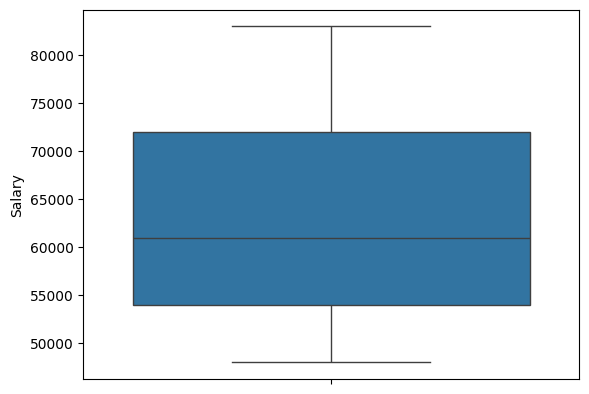

In [5]:
import seaborn as sns
sns.boxplot(data['Salary'])

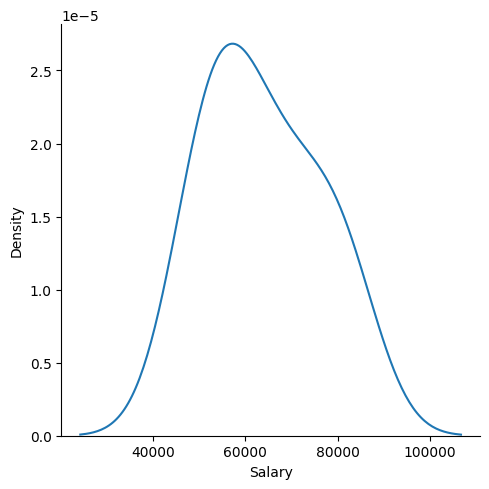

In [6]:
sns.displot(data['Salary'], kind='kde')

In [8]:
data

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,NaN,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [9]:
#Preparing models ----> Inferential Stats
# Two requirements of Inferential Stats to prepare model
# 1. Data must be COMPLETE
# 2. Data must be STRICTLY NUMERIC

In [11]:
#Goal: Create a model that can preedict if the customer will make a purchase in my online app
#.     based on customer's age, estimated salary and customer's location
#
# Features: Country , Age, Salary
# Label: Purchased

In [12]:
# Package : Sci-kit learn
#
# Rule by PN:
# 1. Whenever you are working on sklearn classes/package, ensure the data is reprsented in the form of Numpy Array

In [13]:
data

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,NaN,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [14]:
# Step1: Seperate data as feautures and label

features = data.iloc[:,[0,1,2]].values
label = data.iloc[:,[3]].values

In [16]:
features

array([['France', 44.0, 72000.0],
       ['Spain', 27.0, 48000.0],
       ['Germany', 30.0, 54000.0],
       ['Spain', 38.0, 61000.0],
       ['Germany', 40.0, nan],
       ['France', 35.0, 58000.0],
       ['Spain', nan, 52000.0],
       ['France', 48.0, 79000.0],
       [nan, 50.0, 83000.0],
       ['France', 37.0, 67000.0]], dtype=object)

In [17]:
label

array([['No'],
       ['Yes'],
       ['No'],
       ['No'],
       ['Yes'],
       ['Yes'],
       ['No'],
       ['Yes'],
       ['No'],
       ['Yes']], dtype=object)

In [18]:
# Deal with Missing values ----- Imputation


#Step1: Import relevant library/class

from sklearn.impute import SimpleImputer

#Step2: Instantiate the Object of relevant class

siForCountry = SimpleImputer(missing_values=np.nan, strategy="most_frequent")

#Step3: Fit the data to the object --- Here fit() will compute mode's first value | data['Country'].mode()[0]

siForCountry.fit(features[:,[0]])

#Step4: Transform the data ---> In this case, transform means replace NaN with the mode's first value calc during fit()

features[:,[0]] = siForCountry.transform(features[:,[0]])


In [19]:
features

array([['France', 44.0, 72000.0],
       ['Spain', 27.0, 48000.0],
       ['Germany', 30.0, 54000.0],
       ['Spain', 38.0, 61000.0],
       ['Germany', 40.0, nan],
       ['France', 35.0, 58000.0],
       ['Spain', nan, 52000.0],
       ['France', 48.0, 79000.0],
       ['France', 50.0, 83000.0],
       ['France', 37.0, 67000.0]], dtype=object)

In [ ]:
# llly try for Age and Salary on your own

In [ ]:
# Age --- median
#Step1: Import relevant library

from sklearn.impute import SimpleImputer

#Step2: Instantiate the SimpleImputer Object

siForAge = SimpleImputer(missing_values=np.nan, strategy='median')

#Step3: Fit the data to the object (Internally it will calc the mode of the country column)

siForAge.fit(features[:,[1]])

#Step4: Transform the data ---> In this case, transform means replace nan with the mode value calc above
features[:,[1]] = siForAge.transform(features[:,[1]])

In [ ]:
features

array([['France', 44.0, 72000.0],
       ['Spain', 27.0, 48000.0],
       ['Germany', 30.0, 54000.0],
       ['Spain', 38.0, 61000.0],
       ['Germany', 40.0, nan],
       ['France', 35.0, 58000.0],
       ['Spain', 38.0, 52000.0],
       ['France', 48.0, 79000.0],
       ['France', 50.0, 83000.0],
       ['France', 37.0, 67000.0]], dtype=object)

In [ ]:
# Salary ---- mean
#Step1: Import relevant library

from sklearn.impute import SimpleImputer

#Step2: Instantiate the SimpleImputer Object

siForSalary = SimpleImputer(missing_values=np.nan, strategy='mean')

#Step3: Fit the data to the object (Internally it will calc the mode of the country column)

siForSalary.fit(features[:,[2]])

#Step4: Transform the data ---> In this case, transform means replace nan with the mode value calc above
features[:,[2]] = siForSalary.transform(features[:,[2]])

In [ ]:
features

array([['France', 44.0, 72000.0],
       ['Spain', 27.0, 48000.0],
       ['Germany', 30.0, 54000.0],
       ['Spain', 38.0, 61000.0],
       ['Germany', 40.0, 63777.77777777778],
       ['France', 35.0, 58000.0],
       ['Spain', 38.0, 52000.0],
       ['France', 48.0, 79000.0],
       ['France', 50.0, 83000.0],
       ['France', 37.0, 67000.0]], dtype=object)

In [20]:
# OHE --- on Country Column

from sklearn.preprocessing import OneHotEncoder
oheForCountry = OneHotEncoder(sparse_output=False) # --- Return normal array of OHE values
oheForCountry.fit(features[:,[0]])
countryDummyVariables = oheForCountry.transform(features[:,[0]])


In [21]:
countryDummyVariables

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [22]:
oheForCountry.categories_

[array(['France', 'Germany', 'Spain'], dtype=object)]